In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib 
from sklearn.ensemble import IsolationForest
from sqlalchemy import create_engine
from urllib.parse import quote_plus # <-- ¡AÑADE ESTA LÍNEA!

%matplotlib inline

In [16]:
# Conexión BD Azure PostgreSQL
DB_USER = "myvolt_admin"
DB_PASS = "M%R^N!J%IDKS$8@zya4v"
DB_HOST = "myvolt-db.postgres.database.azure.com"
DB_PORT = "5432"
DB_NAME = "postgres"

# Codificamos la contraseña para manejar caracteres especiales (como @, %, $)
DB_PASS_ENCODED = quote_plus(DB_PASS)

# La cadena de conexión para Azure PostgreSQL DEBE usar SSL
try:
    # Usamos la contraseña codificada (DB_PASS_ENCODED)
    connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require"
    engine = create_engine(connection_string)
    
    # Prueba de conexión
    with engine.connect() as conn:
        print("¡Conexión a Azure PostgreSQL exitosa!")
        
except Exception as e:
    print(f"Error al conectar a Azure: {e}")

¡Conexión a Azure PostgreSQL exitosa!


In [17]:
# Esta consulta busca el 'id_device' usando la MAC Address de tu ESP32
# y trae las últimas 2500 lecturas de potencia.
query = """
SELECT time, power_w
FROM consumption_data
WHERE id_device = (
    SELECT id_device 
    FROM devices 
    WHERE mac_address = 'B0:A7:32:34:54:9C'
)
ORDER BY time DESC
LIMIT 2500; 
"""

# Usamos Pandas para ejecutar la consulta y cargar los datos
df = pd.read_sql_query(query, con=engine)

# Inspeccionamos que se hayan cargado bien
print(f"Se cargaron {len(df)} registros desde la base de datos.")
df.head()

Se cargaron 2065 registros desde la base de datos.


,time,power_w
0,2025-11-06 00:43:37.064463+00:00,79.28
1,2025-11-06 00:43:36.860447+00:00,56.20
2,2025-11-06 00:43:36.658051+00:00,68.69
3,2025-11-06 00:43:36.454460+00:00,77.33
4,2025-11-06 00:43:36.254508+00:00,107.51


In [18]:
# Seleccionamos solo la columna 'power_w' para el entrenamiento
# (Usamos dobles corchetes para que siga siendo un DataFrame)
datos_para_modelo = df[['power_w']]

# Inspeccionamos que se vea bien
print("Datos listos para el modelo:")
datos_para_modelo.head()

Datos listos para el modelo:


,power_w
0,79.28
1,56.20
2,68.69
3,77.33
4,107.51


In [19]:
# 1. ML
# 'contamination' es el porcentaje de datos que *esperamos* que sean anomalías.
# Es un valor que puedes "jugar" (ej. 0.05 para 5%, 0.1 para 10%).
modelo_if = IsolationForest(contamination=0.1, random_state=42)

# 2. Entrenamos el modelo con nuestros datos de potencia
modelo_if.fit(datos_para_modelo)

print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


In [20]:
# Pedimos al modelo que prediga si cada fila es una anomalía
# Devuelve:  1  (si es normal)
# Devuelve: -1  (si es una anomalía)
predicciones = modelo_if.predict(datos_para_modelo)

# Guardamos esas predicciones en una nueva columna en nuestro DataFrame original
df['anomalia_predicha'] = predicciones

# Revisamos las anomalías que encontró
anomalias = df[df['anomalia_predicha'] == -1]
print(f"El modelo detectó {len(anomalias)} anomalías de un total de {len(df)} registros.")

print("\nEjemplos de anomalías encontradas (valores de power_w):")
# Mostramos los valores de potencia que marcó como anómalos
print(anomalias['power_w'].value_counts())

El modelo detectó 205 anomalías de un total de 2065 registros.

Ejemplos de anomalías encontradas (valores de power_w):
power_w
55.82     3
55.72     3
55.47     3
109.50    3
53.46     2
         ..
54.79     1
115.04    1
55.75     1
113.40    1
52.78     1
Name: count, Length: 181, dtype: int64


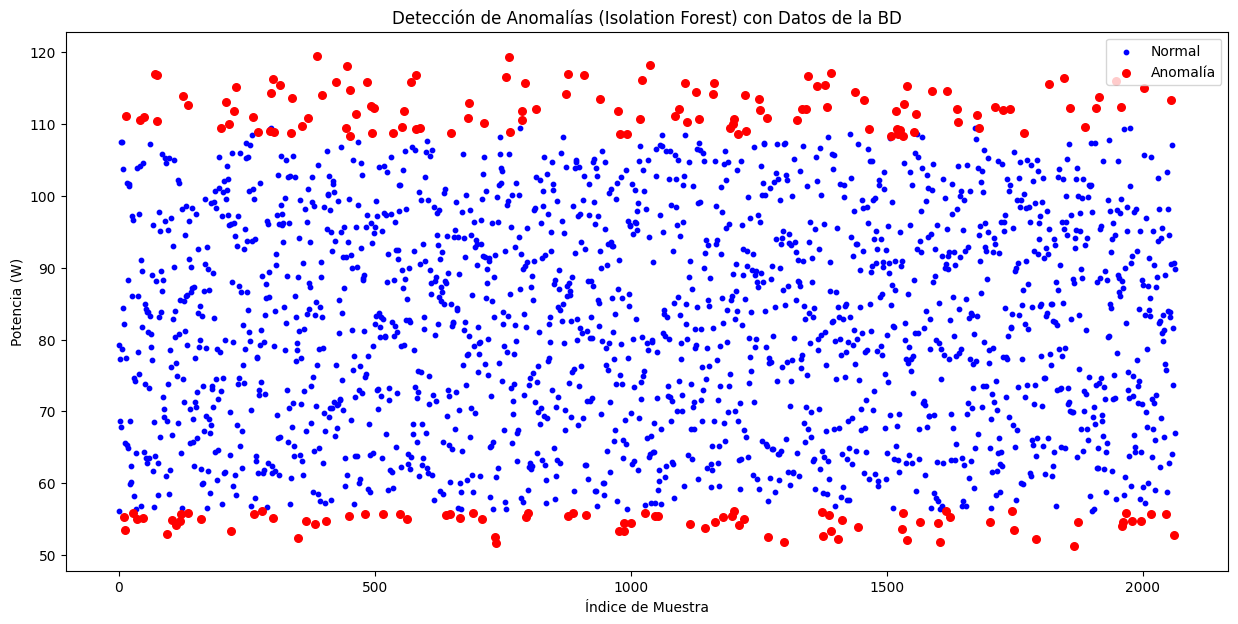

In [23]:
# Separamos los datos normales y los anómalos para pintarlos de colores diferentes
df_normal = df[df['anomalia_predicha'] == 1]
df_anomalo = df[df['anomalia_predicha'] == -1]

# Creamos el gráfico
plt.figure(figsize=(15, 7))

# Pintamos los puntos normales en azul
plt.scatter(df_normal.index, df_normal['power_w'], 
            c='blue', label='Normal', s=10) # s=10 es el tamaño del punto

# Pintamos las anomalías en rojo y más grandes
plt.scatter(df_anomalo.index, df_anomalo['power_w'], 
            c='red', label='Anomalía', s=30)

plt.title('Detección de Anomalías (Isolation Forest) con Datos de la BD')
plt.xlabel('Índice de Muestra')
plt.ylabel('Potencia (W)')
plt.legend()
plt.show()

In [22]:
import joblib

# 1. Definimos la ruta de salida (en la carpeta 'models' que está ignorada por Git)
ruta_modelo = '../models/isolation_forest_model_v1.pkl' 

# 2. Guardamos el modelo entrenado (la variable 'modelo_if') en esa ruta
joblib.dump(modelo_if, ruta_modelo)

print(f"¡Modelo guardado exitosamente en {ruta_modelo}!")

¡Modelo guardado exitosamente en ../models/isolation_forest_model_v1.pkl!
